In [23]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
h,K,L,I,J,k,l,i,j = symbols(['h','K','L','I','J','k','l','i','j'])
alpha,beta,nu,rho,xi,eta,x,y = symbols(['alpha','beta','nu','rho','xi','eta','x','y'])

trap_corners = {}
trap_corners[0] = [(K*h,L*h),((K+1/2)*h,(L+1/4)*h),
                   (K*h,(L+1)*h),((K+1/2)*h,(L+3/4)*h)]
trap_corners[2] = [((K+1/2)*h,(L+1/4)*h),((K+1)*h,L*h),
                   ((K+1/2)*h,(L+3/4)*h),((K+1)*h,(L+1)*h)]
trap_corners[1] = [(K*h,L*h),((K+1)*h,L*h),
                   ((K+1/4)*h,(L+1/2)*h),((K+3/4)*h,(L+1/2)*h)]
trap_corners[3] = [((K+1/4)*h,(L+1/2)*h),((K+3/4)*h,(L+1/2)*h),
                   (K*h,(L+1)*h),((K+1)*h,(L+1)*h)]
tri_corners = {}
tri_corners[0] = [(K*h,L*h),((K+1/2)*h,(L-1/4)*h),((K+1/2)*h,(L+1/4)*h)]
tri_corners[2] = [((K+1)*h,L*h),((K+1/2)*h,(L+1/4)*h),((K+1/2)*h,(L-1/4)*h)]
tri_corners[1] = [(K*h,L*h),((K+1/4)*h,(L+1/2)*h),((K-1/4)*h,(L+1/2)*h)]
tri_corners[3] = [(K*h,(L+1)*h),((K-1/4)*h,(L+1/2)*h),((K+1/4)*h,(L+1/2)*h)]

In [ ]:
tri_transforms,tri_inv_transforms,tri_phi_input = {},{},{}

In [ ]:
trap_transforms,trap_inv_transforms = {},{}
trap_gtransforms,trap_inv_gtransforms = {},{}
simple_vandermond = Matrix([[1,0,0,0],[1,1,0,0],[1,0,1,0],[1,1,1,1]])
def get_vander(map_id,jj):
    if jj == 0:
        return simple_vandermond,[1,nu,rho,nu*rho]

    g_xs = [c[0]/h-K for c in trap_corners[map_id]]
    x0,x1 = [min(g_xs),max(g_xs)]
    g_ys = [c[1]/h-L for c in trap_corners[map_id]]
    y0,y1 = [min(g_ys),max(g_ys)]
    my_vand = Matrix([[1,x0,y0,x0*y0],[1,x1,y0,x1*y0],[1,x0,y1,x0*y1],[1,x1,y1,x1*y1]])

    return my_vand, [1,xi,eta,xi*eta]

var,ref_vars = [x,y],[(nu,rho),(xi,eta)]
forward = [trap_transforms,trap_gtransforms]
backward = [trap_inv_transforms,trap_inv_gtransforms]
for map_id in range(4):
    for jj in range(2):
        forward[jj][map_id] = []
        backward[jj][map_id] = [0,0]

        for ind in range(2):
            rhs = Matrix([c[ind] for c in trap_corners[map_id]])
            vandermond,ref_var_vec = get_vander(map_id,jj)
            coefs = vandermond.solve(rhs)
            forward[jj][map_id].append(sum([var*coef for var,coef in zip(ref_var_vec,coefs)]))

        easy_index = map_id%2
        eq = forward[jj][map_id][easy_index]-var[easy_index]
        easy_ref = solve(eq,ref_vars[jj][easy_index])[0]
        backward[jj][map_id][easy_index] = easy_ref

        other_index = 1-easy_index
        eq = forward[jj][map_id][other_index].subs(ref_vars[jj][easy_index],easy_ref) - var[other_index]
        other_ref = solve(eq,ref_vars[jj][other_index])[0]
        backward[jj][map_id][other_index] = other_ref

In [ ]:
tri_transforms,tri_inv_transforms = {},{}
tri_gtransforms,tri_inv_gtransforms = {},{}

var,ref_vars = [x,y],[alpha,beta]
for map_id in range(4):
    [(xc,yc),(xa,ya),(xb,yb)] = tri_corners[map_id]
    alpha_num = (yc-ya)*(x-xc)+(xa-xc)*(y-yc)
    beta_num = (yb-yc)*(x-xc)+(xc-xb)*(y-yc)
    den = (yb-yc)*(xa-xc)+(xc-xb)*(ya-yc)
    tmp = [(alpha_num/den).simplify(),(beta_num/den).simplify()]
    tri_transforms[map_id] = [(alpha_num/den).simplify(),(beta_num/den).simplify()]

    tmp2 = solve([tmp[0]-alpha,tmp[1]-beta],x,y,dict=False)
    tri_inv_transforms[map_id] = list(tmp2.values())

    shift_index = map_id%2==0
    curr_v = K if map_id%2 else L
    Ltrap_g = [trap_inv_gtransforms[map_id][jj].subs(curr_v,curr_v-1) for jj in range(2)]

In [43]:
eq = trap_transforms[0][0]-x

In [91]:
trap_inv_gtransforms[0][0].subs(K,K-1)

-K + 1 + x/h

In [45]:
solve(eq,nu)

[-2.0*K + 2.0*x/h]

In [36]:
trap_transforms[0][1]

L*h - 0.5*h*nu*rho + 0.25*h*nu + h*rho

In [ ]:
abcd = {0:[(0,0),(1/2,1/4),(0,1),(0,-1/2)],
		2:[(1/2,1/4),(1/2,-1/4),(0,1/2),(0,1/2)],
		1:[(0,0),(1,0),(1/4,1/2),(-1/2,0)],
		3:[(1/4,1/2),(1/2,0),(-1/4,1/2),(1/2,0)]}
inv =  {0:[-1/2,1,0,1,-1,0],
		2:[1/2,1,-1/2,0,1,0],
		1:[1,-1/2,0,1,0,-1],
		3:[1,1/2,-1/2,0,0,1]}
ginv = {0:[1/2,1,0,1,1,0],
		2:[-1/2,1,1/2,2,-1,0],
		1:[1,1/2,0,1,0,1],
		3:[1,-1/2,1/2,2,0,-1]}
ab = {0:[1,-2,0,1,2,0],
	  2:[-1,2,1,-1,-2,1],
	  1:[2,1,0,-2,1,0],
	  3:[-2,-1,1,2,-1,1]}
shift_coefs = {0: [1,2,0],
			   2: [-1,-2,1],
			   1: [-2,1,0],
			   3: [-2,-1,1]}
cstar = {0:(1,-1,0,0),
		 2:(-1,1,1,0),
		 1:(1,1,0,0),
		 3:(-1,-1,0,1)}


In [ ]:

for map_id in range(4):
    (ax,ay),(bx,by),(cx,cy),(dx,dy) = abcd[map_id]
    trap_transforms[map_id] = [h*(K+ax+bx*nu+cx*rho+dx*nu*rho),
                               h*(L+ay+by*nu+cy*rho+dy*nu*rho)]

    ind0,ind1 = map_id%2,map_id%2==0
    pars = [x/h-K,y/h-L]

    for t,mapper in enumerate([inv,ginv]):
        xnum,ynum,cnum,cden,xden,yden = mapper[map_id]
        main = pars[ind0] if t else 2*(pars[ind0]+cnum)

        num = xnum*pars[0]+ynum*pars[1]+cnum
        den = cden+xden*pars[0]+yden*pars[1]

        vars = [main,num/den]
        res = [vars[ind0],vars[ind1]]
        if t:
            trap_phi_input[map_id] = res
            xs,ys,cs = shift_coefs[map_id]
            shft = pars[0]*xs+pars[1]*ys+cs
            shift = shft/(2+shft)
            tmp = res.copy()
            tmp[ind1] -= shift
            tri_phi_input = [tmp[0]+I,tmp[1]+J]
        else:
            trap_inv_transforms[map_id] = [res[0]+I,res[1]+J]

    xa,ya,ca,xb,yb,cb = ab[map_id]
    tri_inv_transforms[map_id] = [xa*pars[0]+ya*pars[1]+ca,xb*pars[0]+yb*pars[1]+cb]
    
    s0,s1,xc,yc = cstar[map_id]
    vars = [s0*(alpha+beta)/2,s1*(alpha-beta)/4]
    tri_transforms[map_id] = [h*(vars[ind0]+K+xc),h*(vars[ind1]+L+yc)]

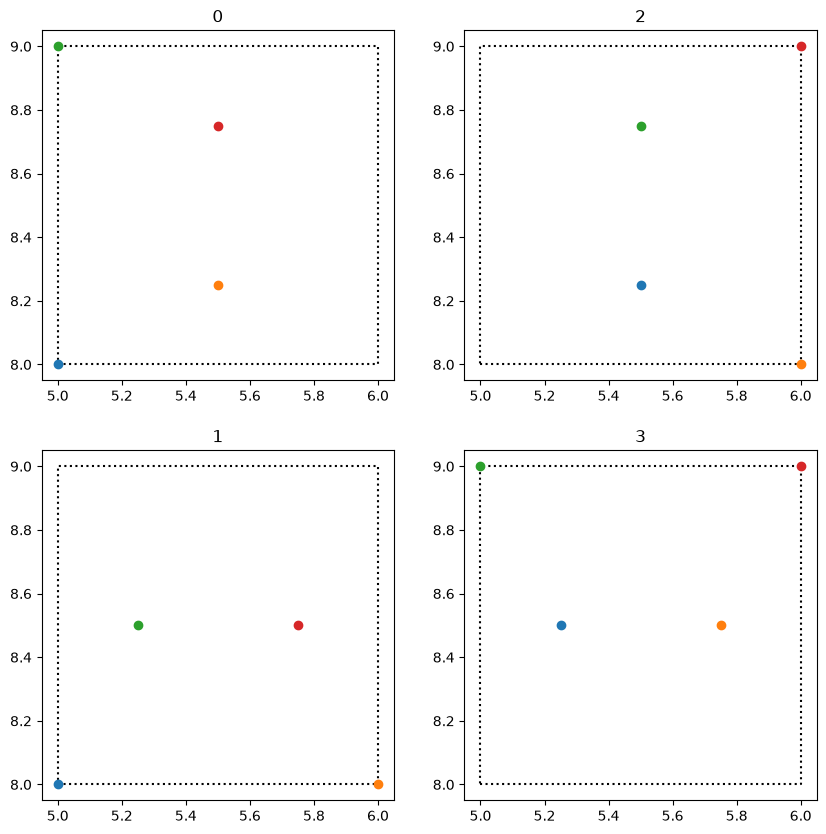

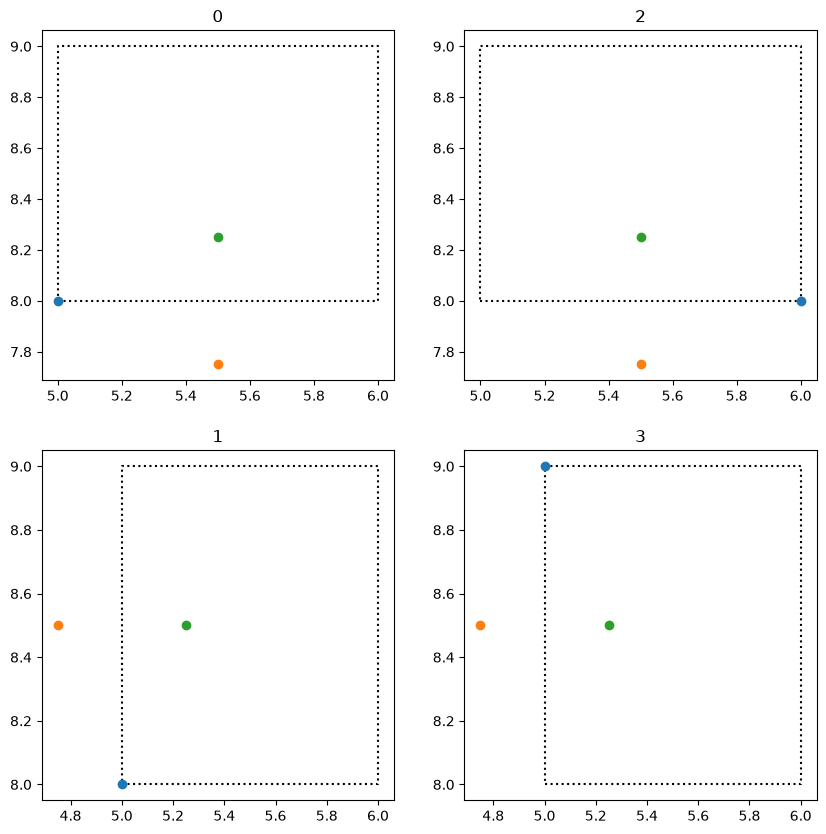

In [22]:
kay,ell,hh = 5,8,1
subd = [(K,kay),(L,ell),(h,hh)]
box = [[kay,kay+hh,kay+hh,kay,kay],[ell,ell,ell+hh,ell+hh,ell]]
fig,ax = plt.subplots(2,2,figsize=(10,10))
for map_id in trap_corners:
    ax[int(map_id%2),int(map_id>1)].plot(box[0],box[1],'k:')
    for c_id,corner in enumerate(trap_corners[map_id]):
        cx = corner[0].subs(subd)
        cy = corner[1].subs(subd)
        ax[int(map_id%2),int(map_id>1)].plot(cx,cy,'C'+str(c_id)+'o')
    ax[int(map_id%2),int(map_id>1)].set_title(map_id)

plt.show()

subd = [(K,5),(L,8),(h,1)]
fig,ax = plt.subplots(2,2,figsize=(10,10))
for map_id in tri_corners:
    ax[int(map_id%2),int(map_id>1)].plot(box[0],box[1],'k:')
    for c_id,corner in enumerate(tri_corners[map_id]):
        cx = corner[0].subs(subd)
        cy = corner[1].subs(subd)
        ax[int(map_id%2),int(map_id>1)].plot(cx,cy,'C'+str(c_id)+'o')
    ax[int(map_id%2),int(map_id>1)].set_title(map_id)

plt.show()

In [ ]:
center = [k,l]
og_center = [K,L]
for map_id in range(4):
    shift_index = map_id%2==0
    shift = [0,0]
    shift[shift_index] = -h
    L_trap = [c+s for (c,s) in zip(center,shift)]
    Lsubs = [(og,curr) for og,curr in zip(og_center,L_trap)]
    R_trap = [c for c in center]
    Rsubs = [(og,curr) for og,curr in zip(og_center,R_trap)]
    Tsubs = [(og,curr) for og,curr in zip(og_center,center)]

    
    
    

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import general_solve

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys  
import tqdm
from scipy import integrate as scint
from tqdm import tqdm
# mypath = 'c:\\Users\\bbarker\\source\\repos\\Galerkin-Differencing\\general_solve'
# sys.path.insert(1, mypath)

In [4]:
plt.rcParams['animation.ffmpeg_path'] = 'C:/Program Files/ffmpeg/bin/ffmpeg.exe'


In [5]:
from general_solve.variable import SingleComponentVariable as Var
from general_solve.run_convergence import run_it, plot_it
from general_solve import globals,debug

In [6]:
import ffmpeg

In [7]:
globals.init()

In [8]:
doflocs = ['node','cell','xside','yside']
rtypes = ['uniform','stripe','square']
rnames = {'uniform':['no'],
		  'stripe':['vertfinecenter',
					'vertcoarsecenter',
					'horzfinecenter',
					'horzcoarsecenter'],
		  'square':['finecenter','coarsecenter']}

u0 = lambda	x: np.sin(2*np.pi*x)+np.cos(2*np.pi*x)
ufunc =	lambda x,y:	u0(x) +	u0(y)
f_lap =	lambda x,y:	-4*np.pi**2*ufunc(x,y)
f_helm = lambda x,y: f_lap(x,y) + ufunc(x,y)

# setup u,v,p,f
mu = 1
rho = 1

u = lambda x,y: -2*np.cos(2*np.pi*x)*np.sin(2*np.pi*y)
ulap = lambda x,y: -8*np.pi**2*u(x,y)

v = lambda x,y: 2*np.sin(2*np.pi*x)*np.cos(2*np.pi*y)
vlap = lambda x,y: -8*np.pi**2*v(x,y)

p = lambda x,y: -np.cos(4*np.pi*x)+np.cos(4*np.pi*y)

f_0 = lambda x,y: 4*np.pi*(2*np.pi*u(x,y)-np.sin(4*np.pi*x))
f_1 = lambda x,y: 4*np.pi*(2*np.pi*v(x,y)+np.sin(4*np.pi*y))

In [9]:
globals.LAG = False

In [10]:
globals.DEBUG = False

In [11]:
N = 8
Zvars = []
for v in [0,1]:
	dofloc = 'xside' if v==0 else 'yside'
	ords = [2,1] if v==0 else [1,2]
	# ords = [3,3]
	rname = 'vertfinecenter' if v==0 else 'horzfinecenter'
	Zvar = Var(N,dofloc=dofloc,var=ufunc,ords=ords,rtype='stripe',rname=rname,zigzag=True)
	Zvars.append(Zvar)


True
False
True
False
{0: [0.25, 0.375, 0.5625, 0.6875], 1: [0.21875, 0.28125, 0.71875, 0.78125]}
{0: [0.3125, 0.3125, 0.6875, 0.6875], 1: [0.25, 0.25, 0.75, 0.75]}
0.6666666666666666 0.16666666666666666
[0.16666666666666666, 0.1666666666666667] [0.1666666666666667, 0.6666666666666666]
None
False
True
False
True
{0: [0.21875, 0.28125, 0.71875, 0.78125], 1: [0.25, 0.375, 0.5625, 0.6875]}
{0: [0.25, 0.25, 0.75, 0.75], 1: [0.3125, 0.3125, 0.6875, 0.6875]}
0.6666666666666666 0.16666666666666666
[0.16666666666666666, 0.1666666666666667] [0.1666666666666667, 0.6666666666666666]
None


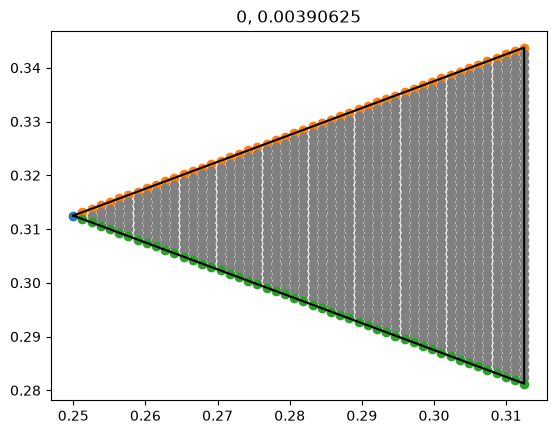

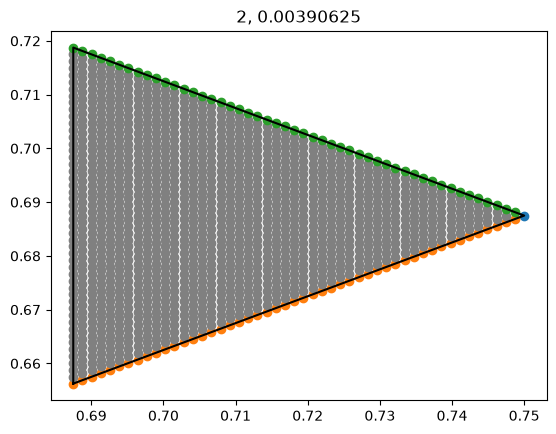

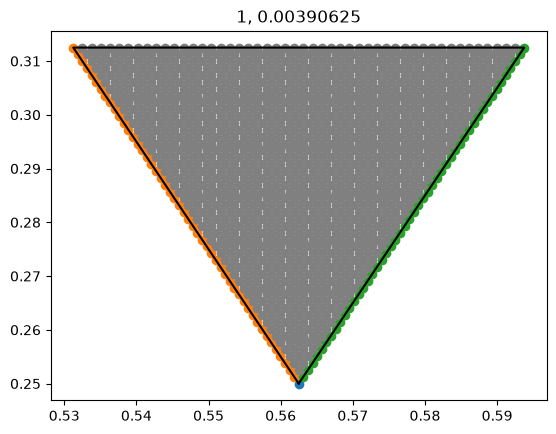

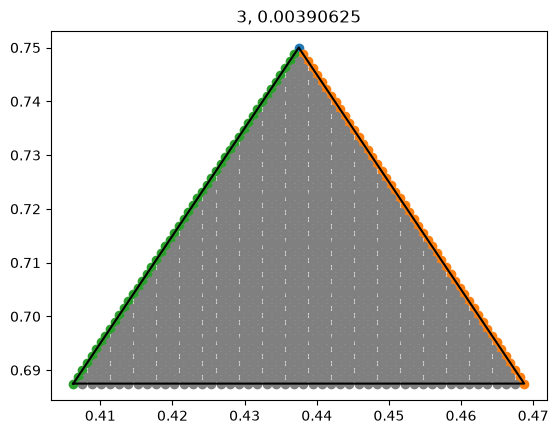

In [12]:
dom = np.linspace(0,1)
for Zvar in Zvars:
    tris = Zvar.mesh.triangle_elements
    my_tris = [tris[4],tris[-5]]
    for e in my_tris:
        for alpha in dom:
            for beta in dom:
                if alpha+beta == 0:
                    col = 'C0'
                elif alpha==0:
                    col='C1'
                elif beta == 0:
                    col='C2'
                else:
                    col='grey'
                if alpha+beta <= 1:
                    x,y = e.transform(alpha,beta)
                    a,b = e.inv_transform(x,y)
                    plt.plot(x,y,'o',c=col)
        plt.title('{}, {}'.format(e.map_type,e.Jt_det()))
        plt.plot(e.to_plot[0],e.to_plot[1],'k')
        plt.show()



In [ ]:
steps = [-3*Zvar.h/2,-Zvar.h,-Zvar.h/2,0,Zvar.h/2,Zvar.h,3*Zvar.h/2]
mini_dom = np.linspace(-3*Zvar.h/2,3*Zvar.h/2)
dom = np.linspace(0,1)
for j,Zvar in enumerate(Zvars):
    done = {.25:False,.25+Zvar.h:False,.75-Zvar.h:False,.75:False}
    for p in Zvar.mesh.patches:
        for dof_id in p.dofs:
            dof = p.dofs[dof_id]
            if dof.h == Zvar.h:
                loc = [dof.x,dof.y]
                if (min(loc) > 2*Zvar.h) and (max(loc) < 1-2*Zvar.h):
                    check = loc[j] in done and done[loc[j]] == False
                    if check:
                        done[loc[j]] = True
                        fig,ax = plt.subplots(2,7,figsize=(70,20))
                        for x in steps:
                            vals = [dof.phi([dof.x+x,dof.y+y]) for y in mini_dom]
                        xlines = [dof.x-2*dof.h,]
                        xs,ys,vals = [],[],[]
                        for e_id in dof.elements:
                            e = dof.elements[e_id]
                            for a in dom:
                                for b in dom:
                                    if not e.tri or a+b<=1:
                                        x,y = e.transform(a,b)
                                        xs.append(x)
                                        ys.append(y)
                                        vals.append(dof.phi([x,y],el=e))
                        plt.scatter(xs,ys,c=vals)
                        plt.colorbar()
                        for e_id in dof.elements:
                            e = dof.elements[e_id]
                            plt.plot(e.to_plot[0],e.to_plot[1],'w')
                        plt.plot(dof.x,dof.y,'ro')
                        plt.show()

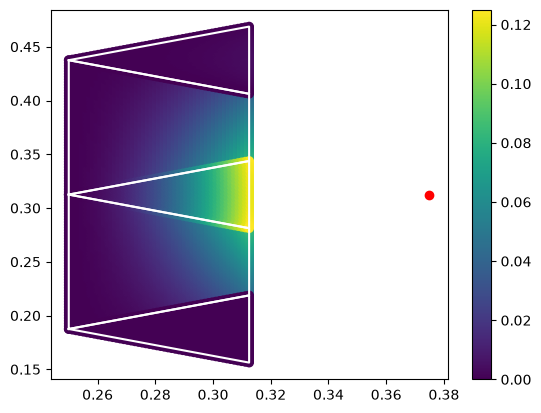

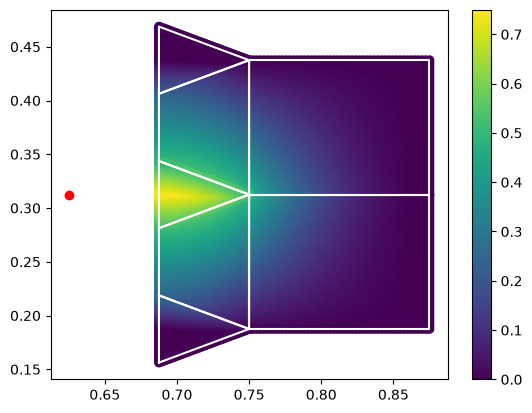

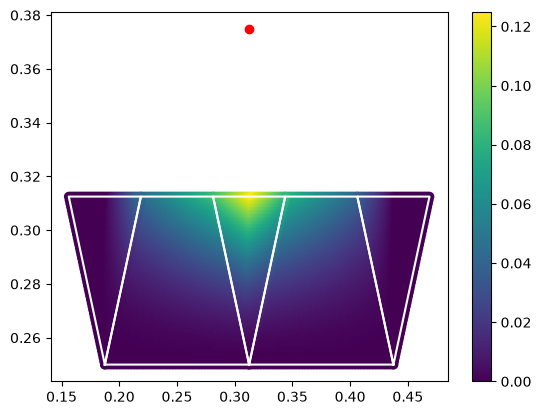

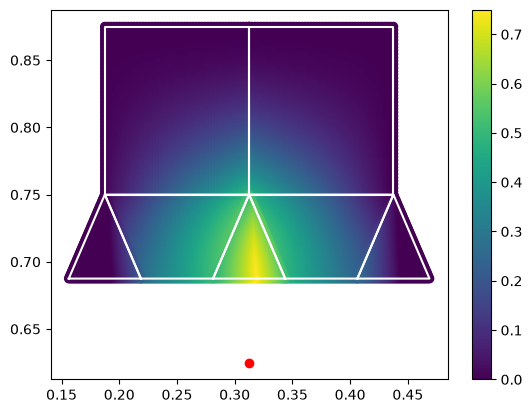

In [37]:
dom = np.linspace(0,1)
for j,Zvar in enumerate(Zvars):
    done = {.25:False,.25+Zvar.h:False,.75-Zvar.h:False,.75:False}
    for p in Zvar.mesh.patches:
        for dof_id in p.dofs:
            dof = p.dofs[dof_id]
            if dof.h == Zvar.h:
                loc = [dof.x,dof.y]
                if (min(loc) > 2*Zvar.h) and (max(loc) < 1-2*Zvar.h):
                    check = loc[j] in done and done[loc[j]] == False
                    if check:
                        done[loc[j]] = True
                        xs,ys,vals = [],[],[]
                        for e_id in dof.elements:
                            e = dof.elements[e_id]
                            for a in dom:
                                for b in dom:
                                    if not e.tri or a+b<=1:
                                        x,y = e.transform(a,b)
                                        xs.append(x)
                                        ys.append(y)
                                        vals.append(dof.phi([x,y],el=e))
                        plt.scatter(xs,ys,c=vals)
                        plt.colorbar()
                        for e_id in dof.elements:
                            e = dof.elements[e_id]
                            plt.plot(e.to_plot[0],e.to_plot[1],'w')
                        plt.plot(dof.x,dof.y,'ro')
                        plt.show()


In [12]:
Zvar._setup_mean_value()

In [13]:
Zvar.solve_poisson(f_lap)

c:\Users\bbarker\source\repos\Galerkin-Differencing\general_solve\pickled
(0, 128)
krylov issue
[-1.96218265]
L2 error     = 5.788715854818433
L1 error     = 13.913150777095192
Linf error   = 10.733728162224141


In [29]:
# Zvar.vis_dof_sol(Zvar.curr_approx_sol,err=True,lines=True,log=False)

In [13]:
dom = np.linspace(0,1,255)
locs = []
for x in dom:
    for y in dom:
        locs.append([x,y])

In [30]:
# Zvar.vis_dof_sol(Zvar.curr_coefs,locs=locs,err=True,lines=True,log=False)

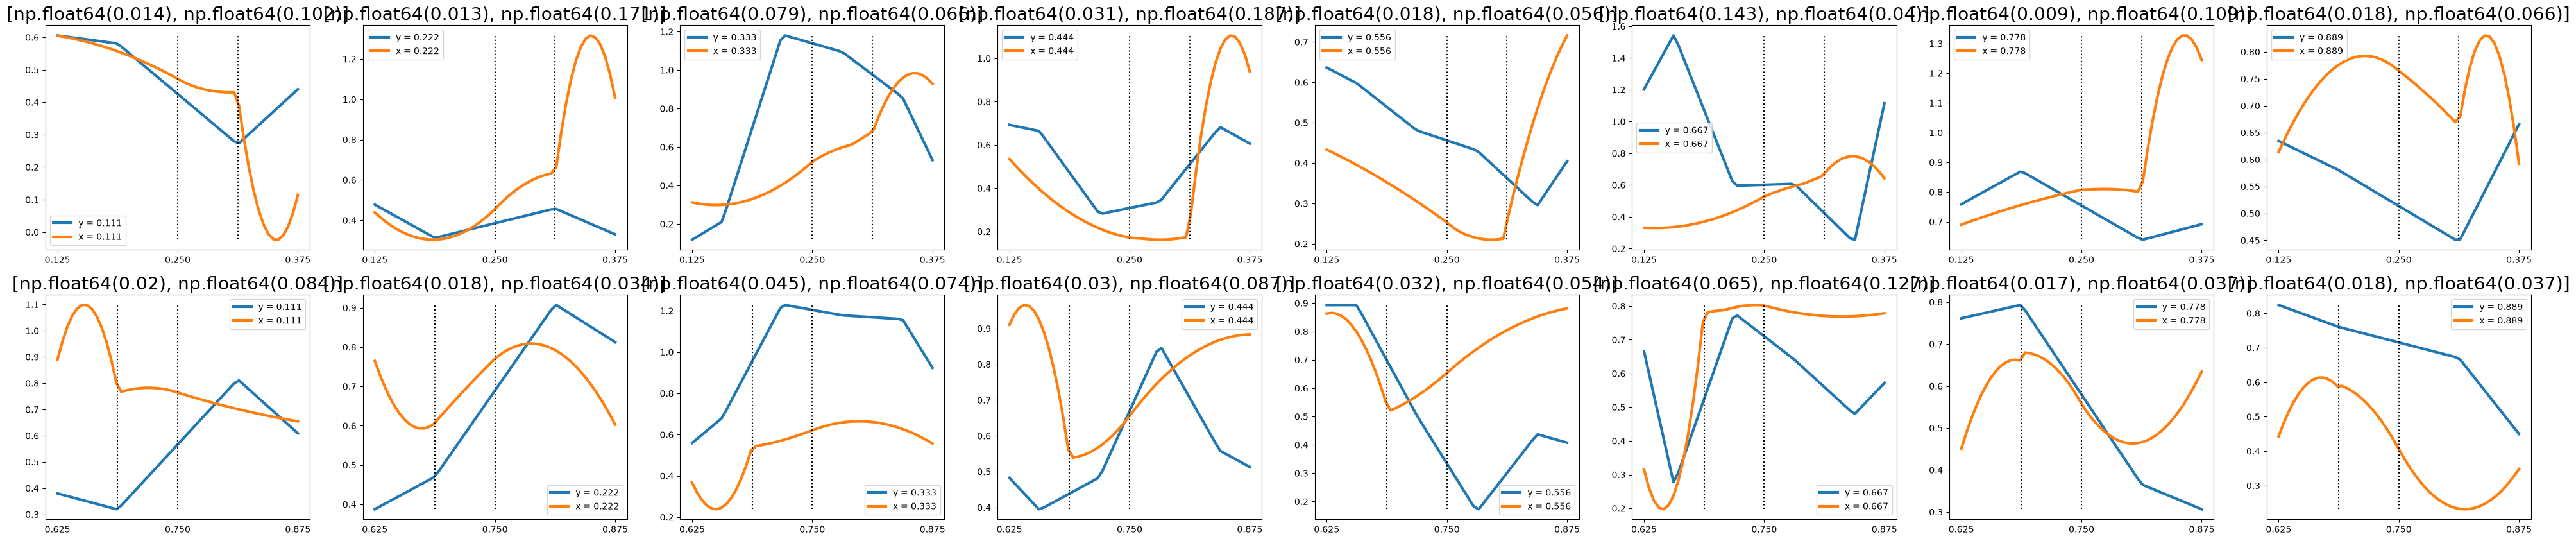

In [38]:
debug.check_continuity(Zvar)

In [65]:
Zvar.solve_projection()

c:\Users\bbarker\source\repos\Galerkin-Differencing\general_solve\pickled
(0, 128)
L2 error     = 2.151738017489544
L1 error     = 3.6098058444984167
Linf error   = 8.20820284978148


In [ ]:
# dof_check = debug.vis_dofs(Zvar,rtype='hstripe')

In [ ]:
# el_check = debug.vis_elements(Zvar,rtype='hstripe')

In [26]:
# dom = np.linspace(0,1)
# for p_id in range(2):
#     for e_id in Zvar.mesh.patches[p_id].elements:
#         e = Zvar.mesh.patches[p_id].elements[e_id]
#         if not e.regular:
#             for nu in dom:
#                 for rho in dom:
#                     if not e.tri or nu+rho<=1:
#                         x,y = e.transform(nu,rho)
#                         plt.plot(x,y,'o')
#             plt.plot(e.to_plot[0],e.to_plot[1],'k')
#             plt.title(e.map_type)
#             plt.show()

            

In [43]:
H = Zvar.h
Jt_trap_det = {0:lambda nu,rho: H**2*(1/2-nu/4),
                2:lambda nu,rho: H**2*(1/4+nu/4),
                1:lambda nu,rho: H**2*(1/2-rho/4),
                3:lambda nu,rho: H**2*(1/4+rho/4)}
P,W = np.polynomial.legendre.leggauss(3)
my_pts = (P+1)/2
Lpts = (P+1)/4
Rpts = (P+3)/4
my_wts = W

my_integral = 0
for py,wy in zip(my_pts,my_wts):
    for px,wx in zip(my_pts,my_wts):
        jdet_val = Jt_trap_det[1](px,py)
        my_integral += jdet_val*wx*wy
Fintegral = my_integral/4

my_integral = 0
for py,wy in zip(my_pts,my_wts):
    for px,wx in zip(Lpts,my_wts):
        jdet_val = Jt_trap_det[1](px,py)
        my_integral += jdet_val*wx*wy

Lintegral = my_integral/8

my_integral = 0
for py,wy in zip(my_pts,my_wts):
    for px,wx in zip(Rpts,my_wts):
        jdet_val = Jt_trap_det[1](px,py)
        my_integral += jdet_val*wx*wy

Rintegral = my_integral/8

print(Lintegral,Rintegral,Lintegral+Rintegral,Fintegral)



0.0029296875 0.0029296875 0.005859375 0.005859375


In [ ]:
import general_solve.barycentric_quadrature as bq

In [ ]:
H = Zvar.h
Jt_tri_det = {0:lambda *args: -H**2/4,2:lambda *args: H**2/4,
                1:lambda *args: H**2/4,3:lambda *args: -H**2/4}
W,[A,B] = bq.get_quad_pts(2)
qpn_count = len(W)

print(H**2/8)
my_integral = 0
for j in range(qpn_count):
    jdet_val = Jt_tri_det[1](0)
    my_integral += jdet_val*W[j]
my_integral

0.6666666666666666 0.16666666666666666
[0.16666666666666666, 0.1666666666666667] [0.1666666666666667, 0.6666666666666666]
0.001953125


1.0

In [55]:
Zvar.interface_map.my_pts[1],Zvar.interface_map.tri_wts

({0: [[0.666666666666667, 0.166666666666667, 0.16666666666666605],
   [0.166666666666667, 0.16666666666666605, 0.666666666666667]]},
 array([0.33333333, 0.33333333, 0.33333333]))

In [61]:
bq.get_quad_pts(2)

0.6666666666666666 0.16666666666666666
[0.16666666666666666, 0.1666666666666667] [0.1666666666666667, 0.6666666666666666]


([0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
 [[0.6666666666666666, 0.16666666666666666, 0.1666666666666667],
  [0.16666666666666666, 0.1666666666666667, 0.6666666666666666]])

In [27]:
debug.check_quadrature(Zvars[1])

True	True	4.279629352029425e-06	2.2418207483981854e-05	2.669783683601128e-05	0.001953125
True	True	8.810653216507352e-06	0.00040763057317945895	0.0003988199199629516	0.001953125
True	True	4.53102637952396e-06	1.7542365169892774e-05	2.2073391549416733e-05	0.001953125
True	True	1.746288994404206e-07	9.476895642738931e-05	9.494358532682973e-05	0.001953125
True	True	5.758411094297731e-07	0.0012120809904156641	0.0012115051493062344	0.001953125
True	True	4.0121079659933114e-07	7.661359482361325e-05	7.701480562021258e-05	0.001953125
True	True	1.2269804238961432e-06	1.0853836142496517e-05	9.626855718600373e-06	0.001953125
True	True	2.5249616129143285e-06	0.00010226629004633358	0.0001047912516592479	0.001953125
True	True	1.2979650261618554e-06	8.950186311169763e-06	7.652221285007908e-06	0.001953125
True	True	4.279629352029425e-06	2.2418207483981854e-05	2.669783683601128e-05	0.001953125
True	True	8.810653216507298e-06	0.00040763057317945895	0.00039881991996295165	0.001953125
True	True	4.53102637

In [18]:
x = np.linalg.solve(Zvar.lhs,Zvar.rhs)

In [32]:
# for j in range(Zvar.constraints.size):
#     if j not in Zvar.constraints.true_dofs:
#         Zvar.constraints.vis_one_constraint(j,rtype='stripe')
# plt.plot([0,0,1,1,0],[0,1,1,0,0],'k')
# plt.plot([0,1],[.25,.25],'k')
# plt.plot([0,1],[.75,.75],'k')
# for p in Zvar.mesh.patches:
#     for d_id in p.dofs:
#         dof = p.dofs[d_id]
#         col = 'r.' if dof.h==Zvar.h else 'b.'
#         plt.plot(dof.x,dof.y,col)
# plt.show()

In [33]:
# Zvar.mesh.view_detailed(split=False)

In [46]:
tmp = Zvars[1]
tst = np.random.random(len(tmp.constraints.true_dofs))
# tst = np.ones_like(tst)

# print(tmp.constraints.spC.shape,tst.shape)
full_tst = tmp.constraints.spC.dot(tst)
full_tst = np.ones_like(full_tst)

mysol = Zvar.sol(full_tst)
# mysol = Zvar.sol(Zvar.curr_coefs)

In [44]:
1/Zvar.h

8.0

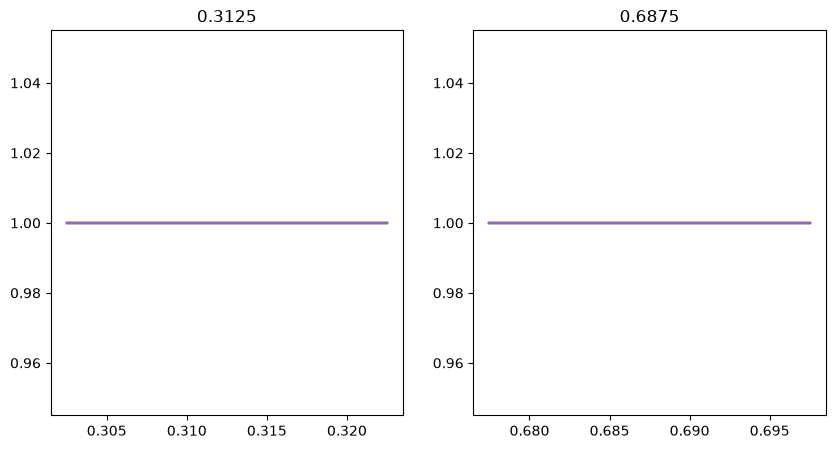

In [47]:
eps = 1e-2
dom = np.linspace(-eps,eps,1000)
fig,ax = plt.subplots(1,2,figsize=(10,5))
spots = [.25+Zvar.h/2,.75-Zvar.h/2]
ysteps = np.linspace(0,1,int(2/Zvar.h+1))[1:-1]
for j in range(2):
	x0 = spots[j]
	for y in ysteps:#range(15):
		# y = np.random.random(1)[0]
		vals = [mysol([y,x0+x]) for x in dom]
		ax[j].plot(x0+dom,vals)
	ax[j].set_title(x0)
plt.show()

In [35]:
# dom = np.linspace(0,1,1000)
# eps = 1e-3
# fig,ax = plt.subplots(1,2,figsize=(10,5))
# for j in range(2):
# 	valsL = [mysol([x,.25+j/2-eps]) for x in dom]
# 	# ax[j].plot(dom,vals,label='LEFT')
# 	valsR = [mysol([x,.25+j/2+eps]) for x in dom]
# 	# ax[j].plot(dom,vals,label='RIGHT')
# 	# ax[j].legend()
# 	errs = [max(abs(vL-vR)-10*eps,0) for (vL,vR) in zip(valsL,valsR)]
# 	# scaled_errs = []
# 	# for err in errs:
# 	# 	if err < eps:
# 	# 		scaled_errs.append(0)
# 	# 	else
# 	# 		scaled_errs.append()
# 	ax[j].plot(dom,errs)
# 	ax[j].set_title(.25+j/2)
# plt.show()

#### stiffness integration checks

In [ ]:
from general_solve import shape_functions as sf

In [ ]:
N = 8
comp = 0
dofloc = 'xside' if comp==0 else 'yside'
ords = [2,1] if comp == 0 else [1,2]
rname = 'vertfinecenter' if comp==0 else 'horzfinecenter'
Zvar = Var(N,dofloc=dofloc,var=ufunc,ords=ords,rtype='stripe',rname=rname,zigzag=True)

In [ ]:
tfunc = lambda x,y: x**2+y**2+x*y
t_func = lambda y,x: tfunc(x,y)
for p in Zvar.mesh.patches:
	for e_id in p.elements:
		e = p.elements[e_id]
		for dof_i in e.dof_list:
			for dof_j in e.dof_list:
				tfunc = lambda x,y: dof_i.dphi([x,y])@dof_j.dphi([x,y])
				t_func = lambda y,x: tfunc(x,y)
		
				integrand = scint.dblquad(t_func,e.x,e.x+e.h,e.y,e.y+e.h)[0]

				func_vals = Zvar.integrator._evaluate_func_on_element(
							tfunc,e.bounds)
				my_integrand = 0
				vol = (e.h/2)**2
				for q_id in range(4):
					u_vals = func_vals[q_id]
					my_integrand += Zvar.integrator._compute_product_integral(
						u_vals,volume=vol)
				# print(round(integrand,8),round(my_integrand,8),sep='\t')
				if not (abs(integrand-my_integrand)<1e-15):
					print('uhoh')

In [ ]:
Zvar.solve_poisson(f_lap)

In [ ]:
id_map = Zvar.integrator.id_map
local_k = Zvar.integrator.k_vals
for p in Zvar.mesh.patches:
	for e_id in p.elements:
		e = p.elements[e_id]
		for i,dof_i in enumerate(e.dof_list):
			for j,dof_j in enumerate(e.dof_list):
				tfunc = lambda x,y: dof_i.dphi([x,y])@dof_j.dphi([x,y])
				t_func = lambda y,x: tfunc(x,y)
		
				integrand = scint.dblquad(t_func,e.x,e.x+e.h,e.y,e.y+e.h)[0]
				my_integrand = 0
				for q_id in range(4):
					my_integrand += local_k[q_id][i,j]
				if not (abs(integrand-my_integrand)<1e-15):
					print('uhoh')

In [ ]:
# let's check quadrature on each element
tfunc = lambda x,y: x**2+y**2+x*y
t_func = lambda y,x: tfunc(x,y)
for e in Zvar.mesh.zigzag_elements:
	if e.tri:
		xs = [c.x for c in e.corners]
		ys = [c.y for c in e.corners]
		xL,xR = min(xs),max(xs)
		yL,yR,yM = min(ys),max(ys),sum(ys)/3
		
		if e.tri:
			if xs.count(xL) > 1:
				y0func = lambda x: (yM-yL)/(xR-xL)*(x-xL)+yL
				y1func = lambda x: (yM-yR)/(xR-xL)*(x-xL)+yR
			else:
				y0func = lambda x: (yL-yM)/(xR-xL)*(x-xR)+yL
				y1func = lambda x: (yR-yM)/(xR-xL)*(x-xR)+yR
		else:
			if ys[0] == yL:
				y0func = lambda x: (x-xL)/2+yL
				y1func = lambda x: (xL-x)/2+yR
			else:
				y0func = lambda x: (xR-x)/2+yL
				y1func = lambda x: (x-xR)/2+yR

		for i,dof_i in enumerate(e.dof_list):
			ixi0,ieta0 = dof_i.ref_shifts[e.global_ID]
			if e.tri:
				dphi_i = lambda x,y: sf.dphi_tri(x,y,e.h,e.bary_coefs,
												dof_i.x,dof_i.y,e.map_type)
			else:
				dphi_i = lambda x,y: sf.dphi_trap(x,y,e.h,e.x,e.y,
												ixi0,ieta0,e.map_type)
			for j,dof_j in enumerate(e.dof_list):
				jxi0,jeta0 = dof_j.ref_shifts[e.global_ID]
				if e.tri:
					dphi_j = lambda x,y: sf.dphi_tri(x,y,e.h,e.bary_coefs,
													dof_j.x,dof_j.y,e.map_type)
					dphi_all = lambda x,y: sf.dphi_tri(x,y,e.h,e.bary_coefs,
											dof_i.x,dof_i.y,e.map_type,dof_j.x,dof_j.y)
				else:
					dphi_j = lambda x,y: sf.dphi_trap(x,y,e.h,e.x,e.y,
													jxi0,jeta0,e.map_type)

					dphi_all = lambda x,y: sf.dphi_trap(x,y,e.h,e.x,e.y,
											ixi0,ieta0,e.map_type,jxi0,jeta0)
				tfunc_i0 = lambda x,y: dphi_i(x,y)[0]#@dphi_j(x,y)
				tfunc_i1 = lambda x,y: dphi_i(x,y)[1]#@dphi_j(x,y)
				tfunc_j0 = lambda x,y: dphi_j(x,y)[0]#@dphi_j(x,y)
				tfunc_j1 = lambda x,y: dphi_j(x,y)[1]#@dphi_j(x,y)
				tfunc = tfunc_i0#lambda x,y: dphi_i(x,y)@dphi_j(x,y)
				# tfuncs = [tfunc_i0,tfunc_i1,tfunc_j0,tfunc_j1]

				for iter in range(1):
					# tfunc = lambda x,y: tfunc_i0(x,y)*tfunc_j0(x,y)+tfunc_i1(x,y)*tfunc_j1(x,y)
					# tfunc = tfuncs[iter]
					_tfunc = dphi_all#_tfuncs[iter]

					t_func = lambda y,x: tfunc(x,y)
					integrand,err = scint.dblquad(t_func,xL,xR,y0func,y1func,epsabs=1e-14)

					local_bounds = [0,1,0,1]
					func_vals = Zvar.integrator._evaluate_func_on_element(
										tfunc,local_bounds,wrap=e.transform)
					# _func_vals = Zvar.integrator._evaluate_func_on_element(
										# _tfunc,local_bounds,wrap=e.transform)
					my_integrand = 0
					# _my_integrand = 0
					vol = .25
					for q_id in range(4):
						j_det = e.J_dets[q_id]
						u_vals = func_vals[q_id]
						# _u_vals = _func_vals[q_id]
						my_integrand += Zvar.integrator._compute_product_integral(
							u_vals,volume=vol,jdet=j_det)
						# _my_integrand += Zvar.integrator._compute_product_integral(
							# _u_vals,volume=vol,jdet=j_det)
					if not (abs(integrand-my_integrand)<1e-15):
						print('uhoh')
						print(abs(integrand-my_integrand))

In [ ]:
# let's check quadrature on each element
k_vals = Zvar.interface_map.k_vals
for e in Zvar.mesh.zigzag_elements:
	if not e.tri:
		xs = [c.x for c in e.corners]
		ys = [c.y for c in e.corners]
		xL,xR = min(xs),max(xs)
		yL,yR,yM = min(ys),max(ys),sum(ys)/3
		
		# if e.tri:
		# 	if xs.count(xL) > 1:
		# 		y0func = lambda x: (yM-yL)/(xR-xL)*(x-xL)+yL
		# 		y1func = lambda x: (yM-yR)/(xR-xL)*(x-xL)+yR
		# 	else:
		# 		y0func = lambda x: (yL-yM)/(xR-xL)*(x-xR)+yL
		# 		y1func = lambda x: (yR-yM)/(xR-xL)*(x-xR)+yR
		# else:
		# 	if ys[0] == yL:
		# 		y0func = lambda x: (x-xL)/2+yL
		# 		y1func = lambda x: (xL-x)/2+yR
		# 	else:
		# 		y0func = lambda x: (xR-x)/2+yL
		# 		y1func = lambda x: (x-xR)/2+yR

		for i,dof_i in enumerate(e.dof_list):
			ixi0,ieta0 = dof_i.ref_shifts[e.global_ID]
			dphi_i = lambda x,y: sf.dphi_trap(x,y,e.h,e.x,e.y,
									 		  ixi0,ieta0,e.map_type)
			for j,dof_j in enumerate(e.dof_list):
				jxi0,jeta0 = dof_j.ref_shifts[e.global_ID]
				# dphi_j = lambda x,y: sf.dphi_trap(x,y,e.h,e.x,e.y,
				# 					  			  jxi0,jeta0,e.map_type)

				tfunc = lambda x,y: sf.dphi_trap(x,y,e.h,e.x,e.y,
										ixi0,ieta0,e.map_type,jxi0,jeta0)
				# tfunc_i0 = lambda x,y: dphi_i(x,y)[0]#@dphi_j(x,y)
				# tfunc_i1 = lambda x,y: dphi_i(x,y)[1]#@dphi_j(x,y)
				# tfunc_j0 = lambda x,y: dphi_j(x,y)[0]#@dphi_j(x,y)
				# tfunc_j1 = lambda x,y: dphi_j(x,y)[1]#@dphi_j(x,y)

				# for tfunc in [tfunc_i0,tfunc_i1,tfunc_j0,tfunc_j1]:

				# t_func = lambda y,x: tfunc(x,y)
				# integrand,err = scint.dblquad(t_func,xL,xR,y0func,y1func,epsabs=1e-14)
				integrand = 0

				local_bounds = [0,1,0,1]
				func_vals = Zvar.integrator._evaluate_func_on_element(
									tfunc,local_bounds,wrap=e.transform)
				my_integrand = 0
				vol = .25
				for q_id in range(4):
					integrand += k_vals[False][e.map_type][q_id][i,j]
					j_det = e.J_dets[q_id]
					u_vals = func_vals[q_id]
					my_integrand += Zvar.integrator._compute_product_integral(
						u_vals,volume=vol,jdet=j_det)
				if not (abs(integrand-my_integrand)<1e-15):
					print('uhoh')
					print(abs(integrand-my_integrand))

In [ ]:
e = Zvar.mesh.zigzag_elements[-15]
print(e.map_type)

dom = np.linspace(0,1)[1:-1]
xis, etas = np.meshgrid(dom,dom)

xs,ys = [],[]
for xi in dom:
	etas = np.linspace(0,1-xi)
	for eta in etas:
		x,y = e.transform(xi,eta)
		xs.append(x)
		ys.append(y)

print([e.h*v for v in e.bary_coefs[2:-1]])
plt.plot(e.to_plot[0],e.to_plot[1],'k')
for c in e.dof_list:#corners:
	xi,eta = e.inv_transform(c.x,c.y)
	print(xi,eta,c.ref_shifts[e.global_ID])
	plt.plot(c.x,c.y,'o')

plt.plot(xs,ys,'o')
plt.show()

In [ ]:
from matplotlib import cm
e = Zvar.mesh.zigzag_elements[-5]
h = e.h
dom = np.linspace(0,1)[1:-1]
xis,etas = [],[]
xs,ys = [],[]
for xi in dom:
	tmpetas = np.linspace(0,1-xi)
	for eta in tmpetas:
		xis.append(xi)
		etas.append(eta)
		x,y = e.transform(xi,eta)
		xs.append(x)
		ys.append(y)
n = len(dom)
m = len(tmpetas)

X,Y = np.array(xs).reshape(n,m), np.array(ys).reshape(n,m)

vals = {i:[] for i in range(4)}
xp,yp,coef0,coef1,coef2,coef3,tmp = e.bary_coefs
for x,y in zip(xs,ys):
	px, py = x-xp, y-yp

	A = coef0*px + coef1*py
	B = coef2*px + coef3*py
	C = 1-A-B
	vals[0].append(A)
	vals[1].append(B)
	vals[2].append(C)
	vals[3].append(.75-y)
	# vals.append(.5+(y-e.mid[1]+.5*(x-e.min[0]))/e.h)
for i in range(4):
	vals[i] = np.array(vals[i]).reshape(n,m)
fig, ax = plt.subplots(1,3,figsize=(30,10),subplot_kw={"projection": "3d"})
# surf = ax.plot_surface(X, Y, vals, cmap=cm.coolwarm,
# 				linewidth=0, antialiased=False)
# fig.colorbar(surf)
for i in range(3):
	surf = ax[i].plot_surface(X, Y, vals[i], cmap=cm.coolwarm,
					linewidth=0, antialiased=False)
	fig.colorbar(surf,location='bottom')
	ax[i].scatter(e.x,e.y,1,marker='o',color='k')#,markersize=10)
plt.show()

plt.plot(e.to_plot[0],e.to_plot[1])
plt.plot(xp,yp,'o')

In [ ]:
e.regular

In [ ]:
sf.bspline3(0,1)

In [ ]:

Zvar = Var(N,dofloc=dofloc,var=ufunc,ords=ords,rtype='stripe',rname=rname,zigzag=True)

In [ ]:
from matplotlib import cm
e = Zvar.mesh.zigzag_elements[-5]
h = e.h
dom = np.linspace(0,1,111)[1:-1]
xis,etas = [],[]
xs,ys = [],[]
for xi in dom:
	tmpetas = np.linspace(0,1-xi,111)[1:-1]
	for eta in tmpetas:
		xis.append(xi)
		etas.append(eta)
		x,y = e.transform(xi,eta)
		xs.append(x)
		ys.append(y)
n = len(dom)
m = len(tmpetas)


X,Y = np.array(xs).reshape(n,m), np.array(ys).reshape(n,m)
locs,titles = ['left','bottom','right'],['deta/dx','deta/dy','phi']

check = 0.
center = 0.
for dof in e.dof_list:
	print(dof.ref_shifts[e.global_ID])
	print(e.inv_transform(dof.x,dof.y))
	x0,y0 = dof.x,dof.y
	fig, ax = plt.subplots(1,3,figsize=(30,10),subplot_kw={"projection": "3d"})
	vals = {0:[],1:[],2:[]}
	for (x,y) in zip(xs,ys):
		dphi = sf.dphi_tri(x,y,e.h,e.bary_coefs,x0,y0,e.map_type,check=check)
		phival = dof.phi([x,y],glob=True,el=e)
		vals[0].append(dphi[0])
		vals[1].append(dphi[1])
		# vals[0].append(phival[0])
		# vals[1].append(phival[1])
		vals[2].append(phival)#[0]*phival[1])

	for c in e.corners:
		print((c.x,c.y),dof.phi([c.x,c.y],glob=True,el=e),sep='\t')
	for j in range(3):
		myv = np.array(vals[j]).reshape(n,m)
		if j == 2: 
			if sum(dof.ref_shifts[e.global_ID]) != 0:
				check += myv
			else:
				center += myv
		surf = ax[j].plot_surface(X, Y, myv, cmap=cm.coolwarm,
						linewidth=0, antialiased=False)
		ax[j].set_title(titles[j])
		fig.colorbar(surf,location=locs[j])
	plt.suptitle([x0,y0])
	plt.show()
fig,ax = plt.subplots(1,3,figsize=(30,10),subplot_kw={"projection":"3d"})
surf = ax[0].plot_surface(X, Y, 1-check, cmap=cm.coolwarm,
				linewidth=0, antialiased=False)
fig.colorbar(surf,location="left")
surf = ax[1].plot_surface(X, Y, center, cmap=cm.coolwarm,
				linewidth=0, antialiased=False)
fig.colorbar(surf,location="bottom")
surf = ax[2].plot_surface(X, Y, check+center, cmap=cm.coolwarm,
				linewidth=0, antialiased=False)
fig.colorbar(surf,location="right")
plt.show()

In [ ]:
xs[0],ys[0]

In [ ]:
e.map_type

In [ ]:
plt.plot(e.to_plot[0],e.to_plot[1])
for dof in e.dof_list:
	ixi0,ieta0 = dof.ref_shifts[e.global_ID]
	plt.plot(dof.x,dof.y,'o',label=[ixi0,ieta0])
plt.legend()
plt.show()

In [ ]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator


# Make data.
dom = np.linspace(0,1)[1:-1]
xis, etas = np.meshgrid(dom,dom)

n,m = xis.shape
xis,etas = xis.flatten(),etas.flatten()

e = Zvar.mesh.zigzag_elements[-3]
xs,ys = [],[]
for (xi,eta) in zip(xis,etas):
	x,y = e.transform(xi,eta)
	xs.append(x)
	ys.append(y)

X,Y = np.array(xs).reshape(n,m), np.array(ys).reshape(n,m)

for dof in e.dof_list:
	ixi0,ieta0 = dof.ref_shifts[e.global_ID]
	print(ixi0,ieta0)
	dphi = lambda x,y: sf.dphi_tri(x,y,e.h,e.min[0],e.mid[1],#e.x,e.y,
										ixi0,ieta0,e.map_type,inv_func=e.inv_transform)
	if True:#for dof2 in e.dof_list:
		# jxi0,jeta0 = dof2.ref_shifts[e.global_ID]
		# dphi_all = lambda x,y: sf.dphi_tri(x,y,e.h,e.min[0],e.min[1],#e.x,e.y,
										# ixi0,ieta0,e.map_type,jxi0,jeta0)
		# vals = np.array([dphi_all(x,y) for (x,y) in zip(xs,ys)]).reshape(n,m)
		vals = np.array([dphi(x,y)[0] for (x,y) in zip(xs,ys)]).reshape(n,m)
		fig, ax = plt.subplots(figsize=(20,20),subplot_kw={"projection": "3d"})
		surf = ax.plot_surface(X, Y, vals, cmap=cm.coolwarm,
							linewidth=0, antialiased=False)
		fig.colorbar(surf,location='left')
		plt.show()
# 	# phi0 = lambda x,y: sf.phi_trap(x,y,e.h,e.x,e.y,
# 	# 									ixi0,ieta0,e.map_type)
# 	# phi1 = lambda x,y: dof.phi([x,y],glob=True)
# 	# vals0 = np.array([phi0(x,y) for (x,y) in zip(xs,ys)]).reshape(n,m)
# 	# vals1 = np.array([phi1(x,y) for (x,y) in zip(xs,ys)]).reshape(n,m)
# 	# diffs = np.array([abs(phi0(x,y)-phi1(x,y)) for (x,y) in zip(xs,ys)]).reshape(n,m)
# 	vals = [dphi(x,y) for (x,y) in zip(xs,ys)]
# 	dx = np.array([v[0] for v in vals]).reshape(n,m)
# 	dy = np.array([v[1] for v in vals]).reshape(n,m)

# 	# fig, ax = plt.subplots(figsize=(20,20),subplot_kw={"projection": "3d"})
# 	fig, ax = plt.subplots(1,2,figsize=(20,10),subplot_kw={"projection": "3d"})
# 	# surf = ax.plot_surface(X, Y, vals, cmap=cm.coolwarm,
# 	# 					linewidth=0, antialiased=False)
	
# # 	fig.colorbar(surf,location='left')
		
# 	surf0 = ax[0].plot_surface(X, Y, dx, cmap=cm.coolwarm,
# 						linewidth=0, antialiased=False)
	
# 	fig.colorbar(surf0,location='left')
# 	surf1 = ax[1].plot_surface(X, Y, dy, cmap=cm.coolwarm,
# 						linewidth=0, antialiased=False)
# 	fig.colorbar(surf1,location='right')

# # # # Customize the z axis.
# # # ax.set_zlim(-1.01, 1.01)
# # # ax.zaxis.set_major_locator(LinearLocator(10))
# # # # A StrMethodFormatter is used automatically
# # # ax.zaxis.set_major_formatter('{x:.02f}')

# # # # Add a color bar which maps values to colors.
# # # fig.colorbar(surf, shrink=0.5, aspect=5)

# 	plt.show()

In [ ]:
dof.ref_shifts

In [ ]:
ind_to_shifts = {0:[1,0],1:[0,0],2:[-1,0],3:[1,-1],4:[0,-1],5:[-1,-1]}
e = Zvar.mesh.zigzag_elements[3]
plt.plot(e.to_plot[0],e.to_plot[1])
for loc_id,dof in enumerate(e.dof_list):
	plt.plot(dof.x,dof.y,'o',label=dof.ref_shifts[e.global_ID])
	print((dof.x-e.x)/e.h,dof.ref_shifts[e.global_ID],ind_to_shifts[loc_id])
plt.legend()
plt.show()